<a href="https://colab.research.google.com/github/RenzoLA26/Challenges/blob/main/Challenge10_LUNA_GALVAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Generate ECG Signals for Arrhythmia Classes using NeuroKit2

In [44]:
# Install neurokit2 if not already installed
!pip install neurokit2
!pip install neurokit2 tensorflow -q


In [45]:
import neurokit2 as nk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define parameters
sampling_rate = 250 # Hz
duration = 5     # seconds for each signal
heart_rates = [40, 90, 120] # bpm for the three classes
num_signals_per_class = 50 # Number of signals to generate for each class

ecg_database = []

for hr in heart_rates:
    print(f"Generating ECG signals for {hr} BPM...")
    for i in range(num_signals_per_class):
        # Simulate an ECG signal with the specified heart rate
        ecg_signal = nk.ecg_simulate(duration=duration, sampling_rate=sampling_rate, heart_rate=hr, noise=0.05)

        # Create a dictionary to store the signal and its metadata
        signal_data = {
            'heart_rate_bpm': hr,
            'class_label': f'{hr}bpm',
            'ecg_signal': ecg_signal
        }
        ecg_database.append(signal_data)

# Convert the list of dictionaries to a pandas DataFrame for easier handling
df_ecg = pd.DataFrame(ecg_database)

print(f"\nGenerated {len(df_ecg)} ECG signals.")
display(df_ecg.head())

Generating ECG signals for 40 BPM...
Generating ECG signals for 90 BPM...
Generating ECG signals for 120 BPM...

Generated 150 ECG signals.


,heart_rate_bpm,class_label,ecg_signal
0,40,40bpm,"[1.0042468387129893, 0.9730424373781524, 0.890..."
1,40,40bpm,"[0.45345917047477524, 0.4341779018118254, 0.38..."
2,40,40bpm,"[1.066836251552585, 1.0349395272813042, 0.9507..."
3,40,40bpm,"[1.0143565661570821, 0.9824183990739651, 0.898..."
4,40,40bpm,"[1.0601552120224502, 1.0270215865143786, 0.939..."


### Visualize a Sample ECG Signal

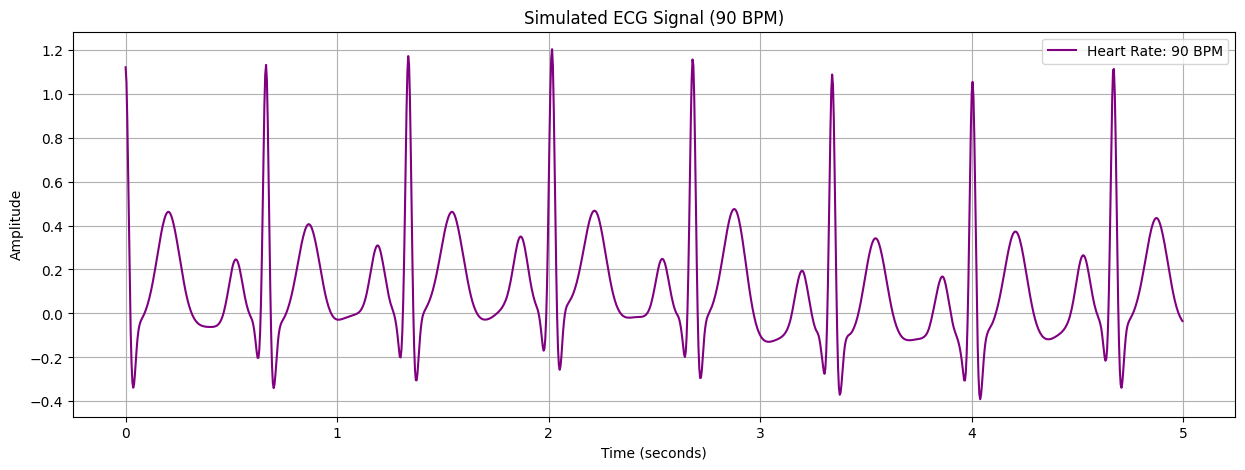

In [46]:
#@title { vertical-output: true}

# Select one signal to visualize (e.g., the first 90bpm signal)
sample_signal_data = df_ecg[df_ecg['class_label'] == '90bpm'].iloc[0]
sample_signal = sample_signal_data['ecg_signal']
sample_hr = sample_signal_data['heart_rate_bpm']

# Create a time vector
time = np.arange(len(sample_signal)) / sampling_rate

plt.figure(figsize=(15, 5))
plt.plot(time, sample_signal, color='purple', label=f'Heart Rate: {sample_hr} BPM')
plt.title(f'Simulated ECG Signal ({sample_hr} BPM)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

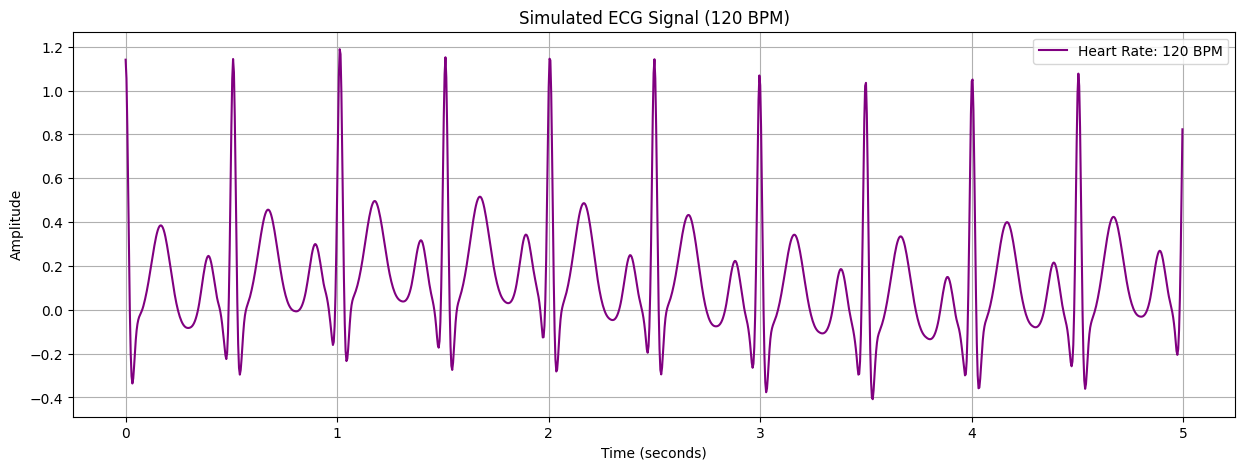

In [47]:
#@title { vertical-output: true}

# Select one signal to visualize (e.g., the first 90bpm signal)
sample_signal_data = df_ecg[df_ecg['class_label'] == '120bpm'].iloc[0]
sample_signal = sample_signal_data['ecg_signal']
sample_hr = sample_signal_data['heart_rate_bpm']

# Create a time vector
time = np.arange(len(sample_signal)) / sampling_rate

plt.figure(figsize=(15, 5))
plt.plot(time, sample_signal, color='purple', label=f'Heart Rate: {sample_hr} BPM')
plt.title(f'Simulated ECG Signal ({sample_hr} BPM)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

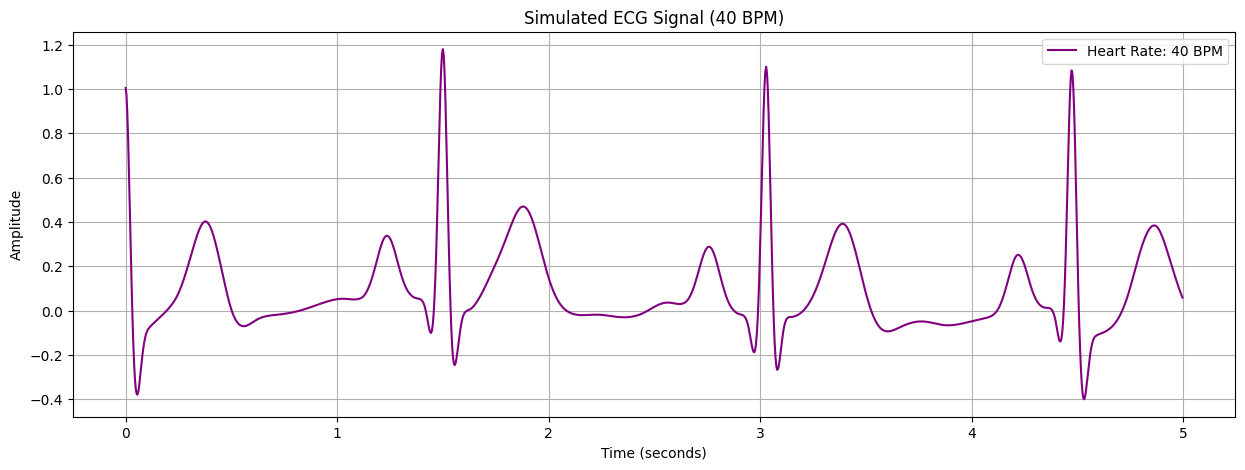

In [48]:
#@title { vertical-output: true}

# Select one signal to visualize (e.g., the first 90bpm signal)
sample_signal_data = df_ecg[df_ecg['class_label'] == '40bpm'].iloc[0]
sample_signal = sample_signal_data['ecg_signal']
sample_hr = sample_signal_data['heart_rate_bpm']

# Create a time vector
time = np.arange(len(sample_signal)) / sampling_rate

plt.figure(figsize=(15, 5))
plt.plot(time, sample_signal, color='purple', label=f'Heart Rate: {sample_hr} BPM')
plt.title(f'Simulated ECG Signal ({sample_hr} BPM)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

In [49]:
df_ecg.head()

,heart_rate_bpm,class_label,ecg_signal
0,40,40bpm,"[1.0042468387129893, 0.9730424373781524, 0.890..."
1,40,40bpm,"[0.45345917047477524, 0.4341779018118254, 0.38..."
2,40,40bpm,"[1.066836251552585, 1.0349395272813042, 0.9507..."
3,40,40bpm,"[1.0143565661570821, 0.9824183990739651, 0.898..."
4,40,40bpm,"[1.0601552120224502, 1.0270215865143786, 0.939..."


In [50]:
df_ecg.groupby("class_label").size()

,0
class_label,
120bpm,50
40bpm,50
90bpm,50


<Axes: ylabel='class_label'>

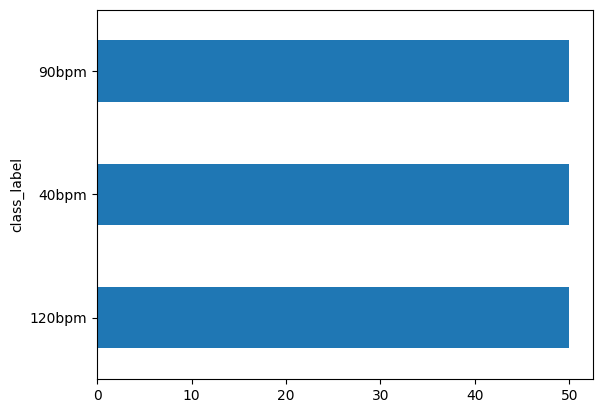

In [51]:
df_ecg.groupby("class_label").size().plot(kind="barh")

In [52]:
df_ecg.to_csv("ecg_database.csv", index=False)

# CHALLENGE

Apartir del dataset sintético de arritmias, extraer caracterśticas relevantes de las clases y crear un modelo clasificador tanto en tensorflow como en arduino usando raspberry pi pico.

Se recomienda usar 3 características relevantes o un PCA de 3 componentes. Deben exportar el firmware a wokwi y probar con 3 potenciometros.

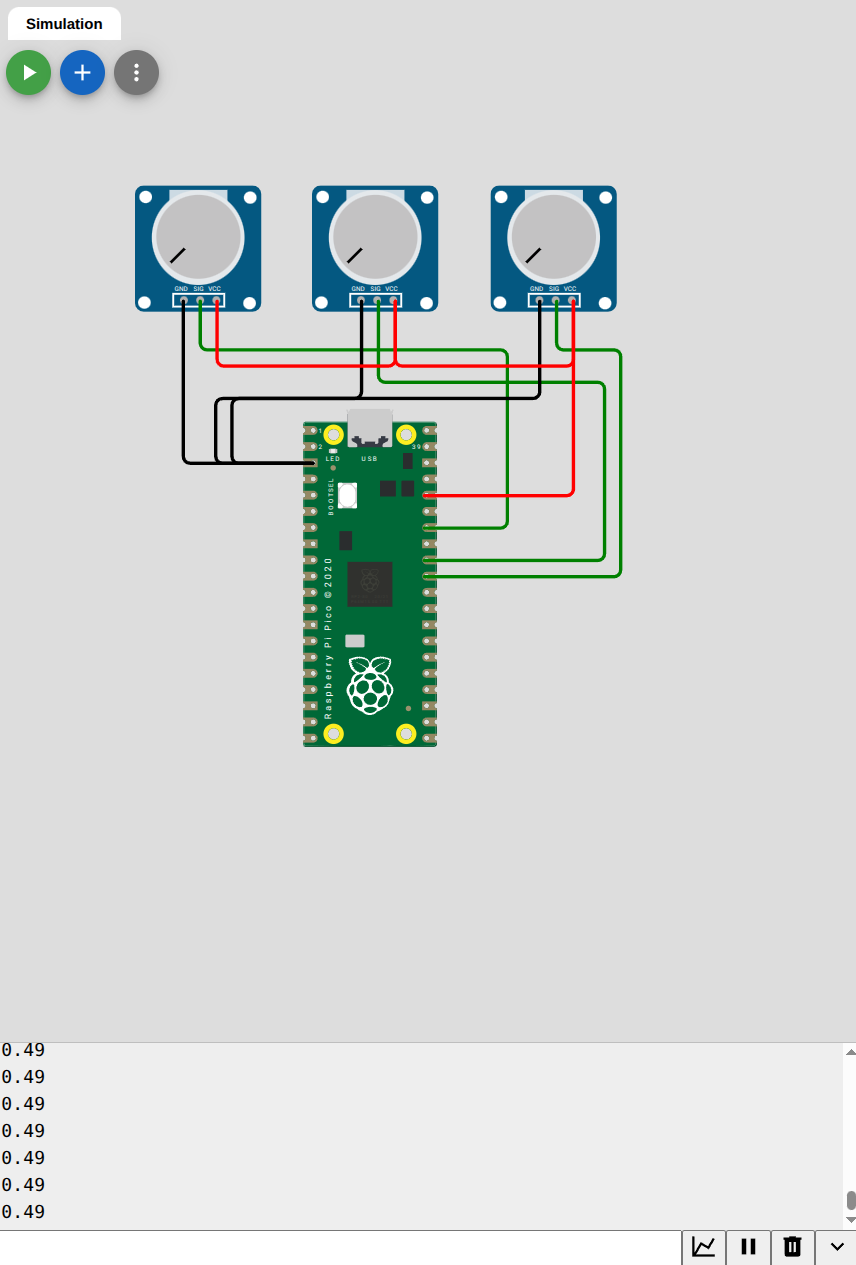

Extraccion de caracteristicas (features)

Se eligió **3 caracteristicas fisiologicamente interpretables**, faciles de
relacionar con un potenciometro cada una en el hardware:

| # | Caracteristica | Que mide | Unidad |
|---|-----------------|----------|--------|
| f0 | `mean_hr` | Frecuencia cardiaca media (a partir de los intervalos RR detectados) | bpm |
| f1 | `sdnn` | Variabilidad de la frecuencia cardiaca (desv. estandar de los RR) | ms |
| f2 | `qrs_amplitude` | Amplitud media del complejo QRS (pico R) | u.a. |

Se calculan con `nk.ecg_peaks` sobre cada señal simulada.

In [53]:
def extract_features(ecg_signal, sampling_rate=250):
    """Extrae 3 caracteristicas relevantes de una senal ECG usando NeuroKit2."""
    try:
        _, rpeaks = nk.ecg_peaks(ecg_signal, sampling_rate=sampling_rate)
        r_peaks = rpeaks["ECG_R_Peaks"]

        if len(r_peaks) < 2:
            return None

        rr_intervals_ms = np.diff(r_peaks) / sampling_rate * 1000.0

        mean_hr = 60000.0 / np.mean(rr_intervals_ms)
        sdnn = np.std(rr_intervals_ms)
        qrs_amplitude = np.mean(np.asarray(ecg_signal)[r_peaks])

        return mean_hr, sdnn, qrs_amplitude
    except Exception:
        return None


feature_rows = []
for _, row in df_ecg.iterrows():
    feats = extract_features(row["ecg_signal"], sampling_rate=sampling_rate)
    if feats is None:
        continue
    feature_rows.append({
        "mean_hr": feats[0],
        "sdnn": feats[1],
        "qrs_amplitude": feats[2],
        "class_label": row["class_label"],
        "heart_rate_bpm": row["heart_rate_bpm"],
    })

df_features = pd.DataFrame(feature_rows)
print(f"Caracteristicas extraidas para {len(df_features)} / {len(df_ecg)} senales")
display(df_features.groupby("class_label")[["mean_hr", "sdnn", "qrs_amplitude"]].describe().T)


Caracteristicas extraidas para 150 / 150 senales


class_label              120bpm      40bpm      90bpm
mean_hr       count   50.000000  50.000000  50.000000
              mean   120.041033  40.031235  90.034573
              std      0.163907   0.376960   0.181877
              min    119.760479  39.421813  89.641434
              25%    119.880120  39.682540  89.910090
              50%    120.000000  40.133797  90.000000
              75%    120.120120  40.363283  90.180361
              max    120.361083  40.705563  90.361446
sdnn          count   50.000000  50.000000  50.000000
              mean     4.028070  23.360000   6.607651
              std      1.015016  18.345616   2.235827
              min      1.732051   2.000000   1.490712
              25%      3.171030   8.500000   4.887274
              50%      4.213075  14.000000   7.086764
              75%      4.898979  38.000000   8.459052
              max      5.454356  60.000000   9.428090
qrs_amplitude count   50.000000  50.000000  50.000000
              mean     1.125598   1.113234   1.133468
              std      0.013325   0.092241   0.013676
              min      1.082532   0.491019   1.083049
              25%      1.117443   1.109010   1.126020
              50%      1.127331   1.128597   1.131174
              75%      1.133920   1.140694   1.144912
              max      1.153803   1.173079   1.158832

## Preparacion de datos: split y escalado

Se usa **escalado min-max** (en vez de estandarizacion) porque es trivial de
reproducir en el microcontrolador con solo dos constantes por caracteristica
(`FEAT_MIN`, `FEAT_MAX`), sin necesidad de calcular medias/desviaciones en el
Pico.

In [54]:
from sklearn.model_selection import train_test_split

classes = [40, 90, 120]
label_to_idx = {c: i for i, c in enumerate(classes)}

X = df_features[["mean_hr", "sdnn", "qrs_amplitude"]].to_numpy(dtype=float)
y = df_features["heart_rate_bpm"].map(label_to_idx).to_numpy()

X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_scaled = (X - X_min) / (X_max - X_min)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("FEAT_MIN:", X_min)
print("FEAT_MAX:", X_max)


X_train: (120, 3)  X_test: (30, 3)
FEAT_MIN: [39.4218134   1.49071198  0.49101922]
FEAT_MAX: [120.36108325  60.           1.17307946]


## Modelo clasificador en TensorFlow/Keras

Arquitectura deliberadamente pequena (3 entradas -> 8 ocultas ReLU -> 3 salidas
Softmax) para que el forward-pass se pueda reimplementar a mano en C++ en el
Raspberry Pi Pico sin necesidad de TensorFlow Lite Micro.

In [55]:
import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(42)

model = models.Sequential([
    layers.Input(shape=(3,)),
    layers.Dense(8, activation="relu", name="hidden"),
    layers.Dense(3, activation="softmax", name="output"),
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=8,
    verbose=0,
)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy en test: {test_acc*100:.1f}%")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden (Dense)                  │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59 (236.00 B)

 Trainable params: 59 (236.00 B)

 Non-trainable params: 0 (0.00 B)

Accuracy en test: 100.0%


              precision    recall  f1-score   support

       40bpm       1.00      1.00      1.00        10
       90bpm       1.00      1.00      1.00        10
      120bpm       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Matriz de confusion:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


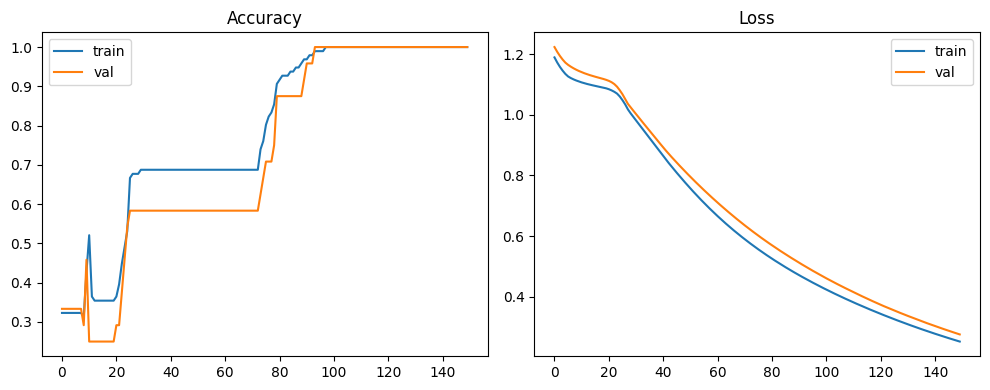

In [56]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

print(classification_report(y_test, y_pred, target_names=[f"{c}bpm" for c in classes]))
print("Matriz de confusion:\n", confusion_matrix(y_test, y_pred))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy"); axes[0].legend()
axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss"); axes[1].legend()
plt.tight_layout()
plt.show()


## Exportar el modelo para Arduino / Raspberry Pi Pico

Se guarda el modelo de Keras (`.h5`) para referencia, y se exportan los pesos
como arreglos de `float` en un header de C (`model_weights.h`) que el firmware
usa para correr el forward-pass a mano (sin TensorFlow Lite Micro).

In [57]:
model.save("arrhythmia_model.h5")

# NOTA: se usan los nombres NET_W1/NET_B1/NET_W2/NET_B2 (en vez de W1/B1/W2/B2)
# porque el core de Arduino para RP2040 (Binary.h) ya define B0..B7 como macros
# de literales binarios (0b1, 0b10, ...) por compatibilidad con AVR. Usar "B1"
# o "B2" como nombre de variable choca con esas macros y el sketch no compila.
NET_W1, NET_B1 = model.get_layer("hidden").get_weights()   # NET_W1: (3,8)  NET_B1: (8,)
NET_W2, NET_B2 = model.get_layer("output").get_weights()   # NET_W2: (8,3) NET_B2: (3,)


def c_array(name, arr):
    flat = arr.flatten()
    vals = ", ".join(f"{v:.8f}f" for v in flat)
    shape_comment = "x".join(str(s) for s in arr.shape)
    return f"// shape: {shape_comment}\nstatic const float {name}[{flat.size}] = {{ {vals} }};\n"


header = []
header.append("// Auto-generado desde el notebook de TensorFlow -- NO editar a mano.")
header.append("// Modelo: 3 entradas -> 8 ocultas (ReLU) -> 3 salidas (Softmax)")
header.append("#pragma once\n")
header.append(f"static const int N_IN = {X.shape[1]};")
header.append(f"static const int N_HIDDEN = {NET_W1.shape[1]};")
header.append(f"static const int N_CLASSES = {len(classes)};\n")
header.append("static const int CLASS_LABELS[N_CLASSES] = {" + ", ".join(str(c) for c in classes) + "};\n")
header.append("// Rangos de las 3 caracteristicas usados para el escalado min-max")
header.append("// f0 = HR medio (bpm), f1 = SDNN (ms), f2 = Amplitud QRS")
header.append(c_array("FEAT_MIN", X_min))
header.append(c_array("FEAT_MAX", X_max))
header.append("// Pesos capa 1 (3x8) y sesgos (8)")
header.append(c_array("NET_W1", NET_W1))
header.append(c_array("NET_B1", NET_B1))
header.append("// Pesos capa 2 (8x3) y sesgos (3)")
header.append(c_array("NET_W2", NET_W2))
header.append(c_array("NET_B2", NET_B2))

with open("model_weights.h", "w") as f:
    f.write("\n".join(header))

print("model_weights.h generado. Descargalo y copialo a la carpeta del sketch de Arduino.")

model_weights.h generado. Descargalo y copialo a la carpeta del sketch de Arduino.


## Verificacion: el forward-pass manual debe coincidir con Keras

Antes de llevar los pesos al microcontrolador, se valida que una
reimplementacion manual en NumPy (identica a la que hara el C++) produce
exactamente las mismas probabilidades que `model.predict`.

In [58]:
def relu(x):
    return np.maximum(0, x)

def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

def manual_forward(x_scaled_row):
    h = relu(x_scaled_row @ NET_W1 + NET_B1)
    o = h @ NET_W2 + NET_B2
    return softmax(o)

sample = X_test[0]
manual = manual_forward(sample)
keras_pred = model.predict(sample.reshape(1, -1), verbose=0)[0]

print("manual:", np.round(manual, 4))
print("keras :", np.round(keras_pred, 4))
assert np.allclose(manual, keras_pred, atol=1e-4), "No coinciden!"
print("OK: el forward-pass manual coincide con TensorFlow.")


manual: [0.8641 0.133  0.003 ]
keras : [0.8641 0.133  0.003 ]
OK: el forward-pass manual coincide con TensorFlow.


# Firmware para Raspberry Pi Pico + simulacion en Wokwi

El firmware  usa `model_weights.h` (el generado en
la celda anterior) para:

1. Leer 3 potenciometros conectados a `GP26`, `GP27`, `GP28` (uno por
   caracteristica: HR medio, SDNN, amplitud QRS).
2. Mapear cada lectura ADC (0-4095) al rango real de esa caracteristica
   (`FEAT_MIN`/`FEAT_MAX`) y normalizarla igual que en el entrenamiento.
3. Correr a mano el forward-pass (3 -> 8 ReLU -> 3 Softmax).
4. Mostrar la clase predicha por Serial

**CODIGO DEL FIRMWARE EN ARDUINO IDE:**

In [59]:
"""
#include <Arduino.h>


#include "model_weights.h"

// ---- Configuracion de pines (segun el cableado de diagram.json) -----------
const int PIN_POT_HR   = 26; // GP26 <- pot2:SIG
const int PIN_POT_SDNN = 27; // GP27 <- pot3:SIG
const int PIN_POT_QRS  = 28; // GP28 <- pot1:SIG

const int ADC_MAX = 4095; // resolucion 12 bits

// ---- Utilidades de la red ---------------------------------------------------
float hidden[N_HIDDEN];
float output[N_CLASSES];

float relu(float x) {
  return x > 0.0f ? x : 0.0f;
}

void softmax(float *x, int n) {
  float m = x[0];
  for (int i = 1; i < n; i++) if (x[i] > m) m = x[i];
  float sum = 0.0f;
  for (int i = 0; i < n; i++) {
    x[i] = expf(x[i] - m);
    sum += x[i];
  }
  for (int i = 0; i < n; i++) x[i] /= sum;
}

// forward-pass manual: identico al validado en Python (train_and_export.py)
int classify(float feat[N_IN], float probs_out[N_CLASSES]) {
  // Capa 1: hidden = ReLU(feat * NET_W1 + NET_B1)
  for (int h = 0; h < N_HIDDEN; h++) {
    float acc = NET_B1[h];
    for (int i = 0; i < N_IN; i++) {
      acc += feat[i] * NET_W1[i * N_HIDDEN + h];
    }
    hidden[h] = relu(acc);
  }

  // Capa 2: output = hidden * NET_W2 + NET_B2
  for (int c = 0; c < N_CLASSES; c++) {
    float acc = NET_B2[c];
    for (int h = 0; h < N_HIDDEN; h++) {
      acc += hidden[h] * NET_W2[h * N_CLASSES + c];
    }
    output[c] = acc;
  }

  softmax(output, N_CLASSES);

  int best = 0;
  for (int c = 1; c < N_CLASSES; c++) if (output[c] > output[best]) best = c;

  for (int c = 0; c < N_CLASSES; c++) probs_out[c] = output[c];
  return best;
}

// Mapea una lectura ADC (0..ADC_MAX) al rango real de la caracteristica
// y luego la normaliza a [0,1] con el mismo min-max usado al entrenar.
float read_feature_scaled(int pin, float feat_min, float feat_max) {
  int raw = analogRead(pin);                    // 0..4095
  float real_value = feat_min + (feat_max - feat_min) * (raw / (float)ADC_MAX);
  float scaled = (real_value - feat_min) / (feat_max - feat_min); // == raw/ADC_MAX
  return scaled;
}

void setup() {
  Serial1.begin(115200);
  delay(500);

  analogReadResolution(12); // Pico: ADC de 12 bits (0..4095)

  Serial1.println("Clasificador de arritmias (40/90/120 bpm) - Raspberry Pi Pico");
  Serial1.println("Pot2(GP26)=HR medio | Pot3(GP27)=SDNN(HRV) | Pot1(GP28)=Amplitud QRS");
}

void loop() {
  float feat[N_IN];
  feat[0] = read_feature_scaled(PIN_POT_HR,   FEAT_MIN[0], FEAT_MAX[0]);
  feat[1] = read_feature_scaled(PIN_POT_SDNN, FEAT_MIN[1], FEAT_MAX[1]);
  feat[2] = read_feature_scaled(PIN_POT_QRS,  FEAT_MIN[2], FEAT_MAX[2]);

  float probs[N_CLASSES];
  int pred = classify(feat, probs);

  Serial1.print("Clase predicha: ");
  Serial1.print(CLASS_LABELS[pred]);
  Serial1.print(" bpm  |  P= [");
  for (int c = 0; c < N_CLASSES; c++) {
    Serial1.print(probs[c], 3);
    if (c < N_CLASSES - 1) Serial1.print(", ");
  }
  Serial1.println("]");

  delay(400);
}
"""

'\n#include <Arduino.h>\n\n\n#include "model_weights.h"\n\n// ---- Configuracion de pines (segun el cableado de diagram.json) -----------\nconst int PIN_POT_HR   = 26; // GP26 <- pot2:SIG\nconst int PIN_POT_SDNN = 27; // GP27 <- pot3:SIG\nconst int PIN_POT_QRS  = 28; // GP28 <- pot1:SIG\n\nconst int ADC_MAX = 4095; // resolucion 12 bits\n\n// ---- Utilidades de la red ---------------------------------------------------\nfloat hidden[N_HIDDEN];\nfloat output[N_CLASSES];\n\nfloat relu(float x) {\n  return x > 0.0f ? x : 0.0f;\n}\n\nvoid softmax(float *x, int n) {\n  float m = x[0];\n  for (int i = 1; i < n; i++) if (x[i] > m) m = x[i];\n  float sum = 0.0f;\n  for (int i = 0; i < n; i++) {\n    x[i] = expf(x[i] - m);\n    sum += x[i];\n  }\n  for (int i = 0; i < n; i++) x[i] /= sum;\n}\n\n// forward-pass manual: identico al validado en Python (train_and_export.py)\nint classify(float feat[N_IN], float probs_out[N_CLASSES]) {\n  // Capa 1: hidden = ReLU(feat * NET_W1 + NET_B1)\n  for (int 

## Pasos para compilar y simular en VS Code
Se simulo en VS Code debido a que la pagina web de wokwi.com no se pudo compilar de manera existosa ya que requiere de un plan con costo para poder compilar archivos medianos o no poder compilar por más de 2 minutos.
1. **Instalación de extensiones**: PlatformIO IDE (compilación) y Wokwi Simulator (simulación de hardware) desde el panel de Extensiones de VS Code.
2. **Activación de licencia**: `tecla F1` → `Wokwi: Request a New License` (licencia gratuita vinculada a una cuenta de Wokwi).
3. **Creación del proyecto**: desde PlatformIO Home → New Project, seleccionando placa Raspberry Pi Pico y framework Arduino.
4. **Configuración del entorno (`platformio.ini`)**: se definió la plataforma comunitaria RP2040 (core arduino-pico) necesaria para compilar para el Pico.
5. **Código del firmware**: `main.cpp` con el forward-pass de la red neuronal (3→8→3) y model_weights.h con los pesos exportados desde el notebook de TensorFlow.
6. **Compilación**: `tecla F1` → "PlatformIO: Build", generando los binarios firmware.bin/firmware.elf en .pio/build/pico/.
7. **Configuración de simulación**: `diagram.json` (circuito: Pico + 3 potenciómetros) y `wokwi.toml` (ruta a los binarios compilados).
8. **Ejecución**: `tecla F1` → `Wokwi: Start Simulator`, visualizando la clasificación de arritmias en tiempo real según los potenciómetros.

 **Código de diagram.json**

In [59]:
"""
{
  "version": 1,
  "author": "RENZO LUNA ALIAGA",
  "editor": "wokwi",
  "parts": [
    { "type": "wokwi-pi-pico", "id": "pico", "top": 54.45, "left": -15.6, "attrs": {} },
    { "type": "wokwi-potentiometer", "id": "pot1", "top": -78.1, "left": -163.4, "attrs": {} },
    { "type": "wokwi-potentiometer", "id": "pot2", "top": -78.1, "left": 105.4, "attrs": {} },
    { "type": "wokwi-potentiometer", "id": "pot3", "top": -78.1, "left": -19.4, "attrs": {} }
  ],
  "connections": [
    [ "pico:GP0", "$serialMonitor:RX", "", [] ],
    [ "pico:GP1", "$serialMonitor:TX", "", [] ],
    [ "pot1:VCC", "pico:3V3", "red", [ "v48", "h181.6", "v67.2" ] ],
    [ "pot3:VCC", "pot2:VCC", "red", [ "v48", "h8.8" ] ],
    [ "pot1:GND", "pico:GND.1", "white", [ "v0" ] ],
    [ "pot3:GND", "pico:GND.1", "white", [ "v28.8", "h-86.4", "v67.2" ] ],
    [ "pot2:GND", "pico:GND.1", "white", [ "v38.4", "h-182.4", "v57.6" ] ],
    [ "pico:GP28", "pot1:SIG", "green", [ "h68.4", "v-115.2", "h-28.8" ] ],
    [ "pot3:SIG", "pico:GP27", "green", [ "v96", "h114.8", "v76.8" ] ],
    [ "pot2:SIG", "pico:GP26", "green", [ "v172.8", "h-0.4" ] ]
  ],
  "dependencies": {}
}
"""

**Código de wokwi.toml**

In [ ]:
"""
[wokwi]
version = 1
firmware = '.pio/build/pico/firmware.uf2'
elf = '.pio/build/pico/firmware.elf
"""

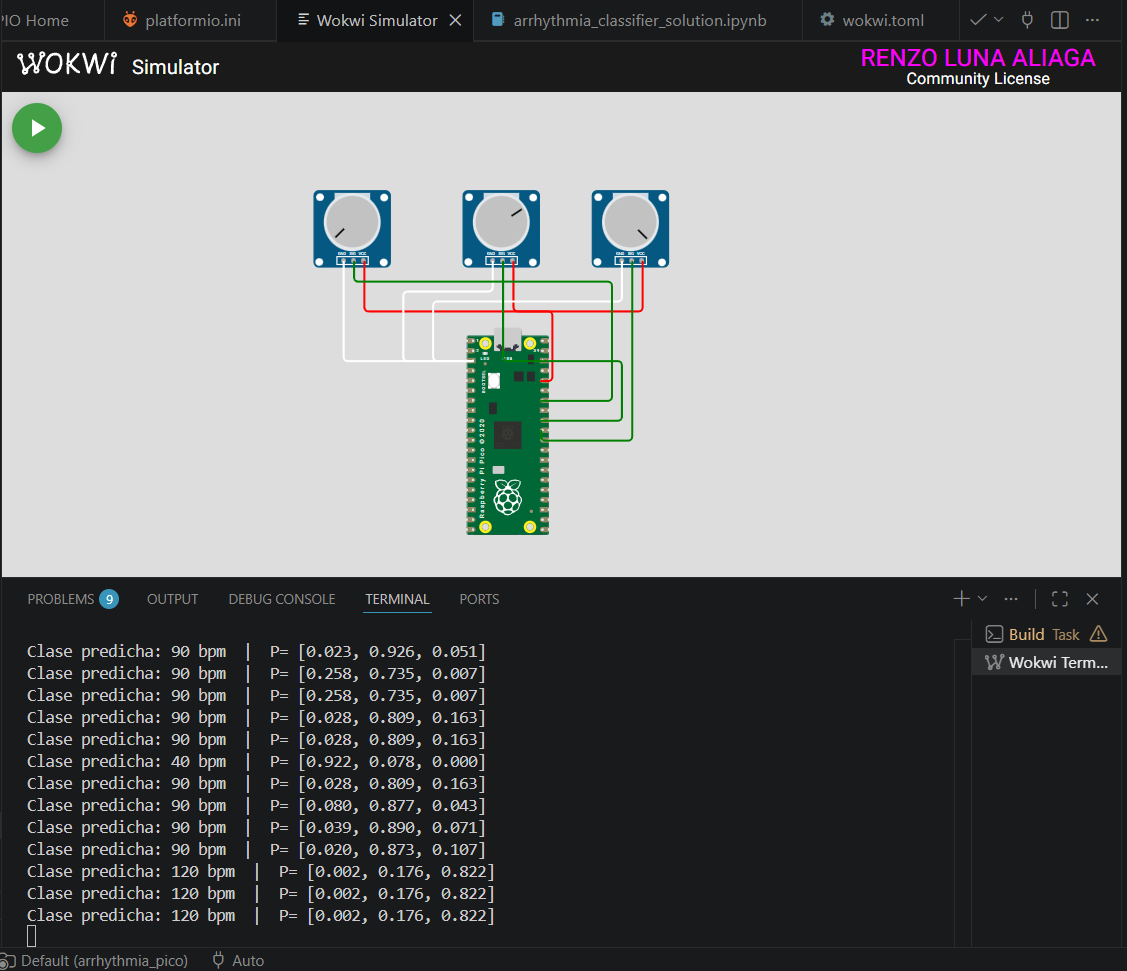